# Greeks — Option Price Sensitivities

## Why this matters

Greeks are how desks **talk**. "Long 5,000 vega, short 200 gamma at the 100 strike, charmed for delta drift" is a real trader sentence. Without fluent Greeks vocabulary you can't:

- Hedge a position (delta to flat the directional risk; gamma for the curvature; vega for vol exposure)
- Attribute P&L (decompose daily change into δ × ΔS + ½γ × ΔS² + ν × Δσ + θ × Δt + ...)
- Price exotic risk (vanna and volga drive smile-aware hedging on FX exotics)
- Make a market (you need to know how your inventory bleeds with time and spot moves)

You will be asked, in some order, at every IB quant interview:

1. State and derive the BS delta. Why isn't the ATM call delta exactly 0.5?
2. Explain gamma. Where is it largest? Why?
3. Explain vega. What's a "vega-neutral" portfolio?
4. Explain theta. Why is it negative for long options?
5. Show that gamma-P&L = -theta-P&L for a delta-hedged option (the gamma-theta trade).
6. What's vanna? When does it matter?
7. Compute Greeks via finite differences and explain when you'd prefer that to closed-form.

This notebook covers all of these on real AAPL data with closed-form derivations, finite-difference verification, and a delta-hedging P&L simulation.

## The 30-second concept

**A Greek is a partial derivative of the option price with respect to one input.** Different Greeks tell you how the option behaves when one input moves and others are fixed.

| Greek | Symbol | $\partial$ of price w.r.t. | Why you care |
|---|---|---|---|
| Delta | $\Delta$ | spot $S$ | how much underlying do I need to hedge? |
| Gamma | $\Gamma$ | spot $S$ (second order) | how fast does my delta change? |
| Vega | $\nu$ | volatility $\sigma$ | what's my exposure to vol shifts? |
| Theta | $\Theta$ | time $t$ | how much do I bleed per day if nothing moves? |
| Rho | $\rho$ | risk-free rate $r$ | rate sensitivity |
| Vanna | — | $\partial \Delta / \partial \sigma$ | how does my hedge ratio change with vol? |
| Volga | — | $\partial \nu / \partial \sigma$ | smile curvature exposure |
| Charm | — | $\partial \Delta / \partial t$ | how does my delta drift with time? |

The first five are first-order sensitivities (mostly). The last three are cross-second-order — they matter for **smile-aware** hedging.

## Closed-form Greeks under BS-Merton

For a European call/put with continuous dividend yield $q$, with $d_1, d_2$ as in notebook 01:

| Greek | Call | Put |
|---|---|---|
| $\Delta$ | $e^{-q\tau} N(d_1)$ | $-e^{-q\tau} N(-d_1)$ |
| $\Gamma$ | $\dfrac{e^{-q\tau} \phi(d_1)}{S \sigma \sqrt{\tau}}$ | (same) |
| $\nu$ | $S e^{-q\tau} \phi(d_1) \sqrt{\tau}$ | (same) |
| $\Theta$ | $-\dfrac{S e^{-q\tau} \phi(d_1) \sigma}{2\sqrt{\tau}} - r K e^{-r\tau} N(d_2) + q S e^{-q\tau} N(d_1)$ | $-\dfrac{S e^{-q\tau} \phi(d_1) \sigma}{2\sqrt{\tau}} + r K e^{-r\tau} N(-d_2) - q S e^{-q\tau} N(-d_1)$ |
| $\rho$ | $K \tau e^{-r\tau} N(d_2)$ | $-K \tau e^{-r\tau} N(-d_2)$ |
| Vanna | $-e^{-q\tau} \phi(d_1) \dfrac{d_2}{\sigma}$ | (same) |
| Volga | $\nu \cdot \dfrac{d_1 d_2}{\sigma}$ | (same) |
| Charm (call) | $q e^{-q\tau} N(d_1) - e^{-q\tau} \phi(d_1) \dfrac{2(r-q)\tau - d_2 \sigma\sqrt{\tau}}{2\tau \sigma\sqrt{\tau}}$ | sign-flipped on the $q$ term |

**φ** is the standard normal **PDF**, **N** is the **CDF**. Don't confuse them.

> **Interview note**: Gamma, vega and volga are the **same for calls and puts** — they're "shape" Greeks. Delta, theta, rho and charm are sign-dependent — those are "direction" Greeks. This split is worth memorising.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import pickle
from pathlib import Path

with open('../data/aapl_options_snapshot.pkl', 'rb') as f:
    aapl = pickle.load(f)

S0      = aapl['spot']
T       = aapl['T_days'] / 365.0
expiry  = aapl['expiry']
calls   = aapl['calls']
puts    = aapl['puts']

r, q = 0.043, 0.005

# Reusable from notebook 01
def black_scholes(S, K, T, r, sigma, option_type='call', q=0.0):
    if T <= 0:
        return np.maximum(S - K, 0.0) if option_type == 'call' else np.maximum(K - S, 0.0)
    d1 = (np.log(S/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

print(f'AAPL spot: ${S0:.2f}, T = {T:.4f}y ({aapl["T_days"]} days)')

AAPL spot: $281.68, T = 0.0767y (28 days)


## Implementation — closed-form Greeks

In [2]:
def _d1_d2(S, K, T, r, sigma, q):
    d1 = (np.log(S/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return d1, d2


def bs_delta(S, K, T, r, sigma, option_type='call', q=0.0):
    d1, _ = _d1_d2(S, K, T, r, sigma, q)
    if option_type == 'call':
        return np.exp(-q*T) * norm.cdf(d1)
    return -np.exp(-q*T) * norm.cdf(-d1)


def bs_gamma(S, K, T, r, sigma, q=0.0):
    d1, _ = _d1_d2(S, K, T, r, sigma, q)
    return np.exp(-q*T) * norm.pdf(d1) / (S * sigma * np.sqrt(T))


def bs_vega(S, K, T, r, sigma, q=0.0):
    d1, _ = _d1_d2(S, K, T, r, sigma, q)
    return S * np.exp(-q*T) * norm.pdf(d1) * np.sqrt(T)


def bs_theta(S, K, T, r, sigma, option_type='call', q=0.0):
    d1, d2 = _d1_d2(S, K, T, r, sigma, q)
    common = -(S * np.exp(-q*T) * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
    if option_type == 'call':
        return common - r*K*np.exp(-r*T)*norm.cdf(d2) + q*S*np.exp(-q*T)*norm.cdf(d1)
    return common + r*K*np.exp(-r*T)*norm.cdf(-d2) - q*S*np.exp(-q*T)*norm.cdf(-d1)


def bs_rho(S, K, T, r, sigma, option_type='call', q=0.0):
    _, d2 = _d1_d2(S, K, T, r, sigma, q)
    if option_type == 'call':
        return K*T*np.exp(-r*T)*norm.cdf(d2)
    return -K*T*np.exp(-r*T)*norm.cdf(-d2)


def bs_vanna(S, K, T, r, sigma, q=0.0):
    d1, d2 = _d1_d2(S, K, T, r, sigma, q)
    return -np.exp(-q*T) * norm.pdf(d1) * d2 / sigma


def bs_volga(S, K, T, r, sigma, q=0.0):
    d1, d2 = _d1_d2(S, K, T, r, sigma, q)
    vega = S * np.exp(-q*T) * norm.pdf(d1) * np.sqrt(T)
    return vega * d1 * d2 / sigma


def bs_charm(S, K, T, r, sigma, option_type='call', q=0.0):
    d1, d2 = _d1_d2(S, K, T, r, sigma, q)
    common = -np.exp(-q*T) * norm.pdf(d1) * (2*(r-q)*T - d2*sigma*np.sqrt(T)) / (2*T*sigma*np.sqrt(T))
    if option_type == 'call':
        return q*np.exp(-q*T)*norm.cdf(d1) + common
    return -q*np.exp(-q*T)*norm.cdf(-d1) + common


# Smoke check on Hull-textbook ATM call (S=42, K=40, r=0.10, σ=0.2, T=0.5, q=0)
S_, K_, T_, r_, sig_ = 42, 40, 0.5, 0.10, 0.20
greeks = {
    'price': black_scholes(S_, K_, T_, r_, sig_, 'call'),
    'delta': bs_delta(S_, K_, T_, r_, sig_, 'call'),
    'gamma': bs_gamma(S_, K_, T_, r_, sig_),
    'vega':  bs_vega (S_, K_, T_, r_, sig_),
    'theta': bs_theta(S_, K_, T_, r_, sig_, 'call'),
    'rho':   bs_rho  (S_, K_, T_, r_, sig_, 'call'),
}
print('Hull textbook ATM call Greeks:')
for k, v in greeks.items():
    print(f'  {k:6s}: {v:.6f}')

Hull textbook ATM call Greeks:
  price : 4.759422
  delta : 0.779131
  gamma : 0.049963
  vega  : 8.813415
  theta : -4.559092
  rho   : 13.982046


## Verification — finite differences

In [3]:
# Cross-check every closed-form Greek against bumping the input.
# Use central differences with bump h chosen for each input.
S_, K_, T_, r_, sig_, q_ = 100, 100, 0.5, 0.05, 0.30, 0.02

def fd_greek(price_fn, var_index, h, *args):
    """Central-difference partial derivative."""
    args_up   = list(args); args_up[var_index]   = args[var_index] + h
    args_down = list(args); args_down[var_index] = args[var_index] - h
    return (price_fn(*args_up) - price_fn(*args_down)) / (2 * h)

V = lambda S, K, T, r, sigma, q: black_scholes(S, K, T, r, sigma, 'call', q)

rows = []
# (name, closed-form value, FD value, bump size on which input)
rows.append(('delta', bs_delta(S_, K_, T_, r_, sig_, 'call', q_),
             fd_greek(V, 0, 0.01, S_, K_, T_, r_, sig_, q_), 'S, h=0.01'))
rows.append(('gamma', bs_gamma(S_, K_, T_, r_, sig_, q_),
             (V(S_+0.5, K_, T_, r_, sig_, q_) - 2*V(S_, K_, T_, r_, sig_, q_) + V(S_-0.5, K_, T_, r_, sig_, q_))/0.5**2,
             'S, second diff h=0.5'))
rows.append(('vega',  bs_vega (S_, K_, T_, r_, sig_, q_),
             fd_greek(V, 4, 0.0001, S_, K_, T_, r_, sig_, q_), 'σ, h=0.0001'))
# Theta = ∂V/∂t = -∂V/∂T (calendar time vs time-to-expiry)
rows.append(('theta', bs_theta(S_, K_, T_, r_, sig_, 'call', q_),
             -fd_greek(V, 2, 0.0001, S_, K_, T_, r_, sig_, q_), 'T, h=0.0001 (sign-flipped)'))
rows.append(('rho',   bs_rho  (S_, K_, T_, r_, sig_, 'call', q_),
             fd_greek(V, 3, 0.0001, S_, K_, T_, r_, sig_, q_), 'r, h=0.0001'))

# Second-order
def vega_fn(S, K, T, r, sigma, q): return bs_vega(S, K, T, r, sigma, q)
rows.append(('vanna', bs_vanna(S_, K_, T_, r_, sig_, q_),
             fd_greek(lambda *a: bs_delta(*a[:5], 'call', a[5]), 4, 0.0001, S_, K_, T_, r_, sig_, q_), 'σ on Δ, h=0.0001'))
rows.append(('volga', bs_volga(S_, K_, T_, r_, sig_, q_),
             fd_greek(vega_fn, 4, 0.0001, S_, K_, T_, r_, sig_, q_), 'σ on vega, h=0.0001'))

print(f'{"Greek":7s}  {"Closed-form":>14s}  {"FD":>14s}  {"abs err":>10s}  bump')
for name, cf, fd, bump in rows:
    err = abs(cf - fd)
    print(f'{name:7s}  {cf:14.8f}  {fd:14.8f}  {err:10.2e}  {bump}')

Greek       Closed-form              FD     abs err  bump
delta        0.56448493      0.56448493    5.60e-09  S, h=0.01
gamma        0.01833053      0.01832988    6.50e-07  S, second diff h=0.5
vega        27.49579441     27.49579440    1.34e-08  σ, h=0.0001
theta       -9.48927510     -9.48927514    4.31e-08  T, h=0.0001 (sign-flipped)
rho         23.69506645     23.69506639    6.02e-08  r, h=0.0001
vanna        0.04582632      0.04582631    1.02e-08  σ on Δ, h=0.0001
volga       -0.57282905     -0.57282895    1.03e-07  σ on vega, h=0.0001


## Validation — QuantLib

In [4]:
import QuantLib as ql

def quantlib_greeks(S, K, T, r, sigma, option_type, q):
    today    = ql.Date.todaysDate()
    maturity = today + int(round(T * 365))
    ql.Settings.instance().evaluationDate = today

    payoff   = ql.PlainVanillaPayoff(ql.Option.Call if option_type=='call' else ql.Option.Put, K)
    exercise = ql.EuropeanExercise(maturity)
    option   = ql.VanillaOption(payoff, exercise)

    spot_h  = ql.QuoteHandle(ql.SimpleQuote(S))
    rate_ts = ql.YieldTermStructureHandle(ql.FlatForward(today, r, ql.Actual365Fixed()))
    div_ts  = ql.YieldTermStructureHandle(ql.FlatForward(today, q, ql.Actual365Fixed()))
    vol_ts  = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(today, ql.NullCalendar(), sigma, ql.Actual365Fixed()))
    process = ql.BlackScholesMertonProcess(spot_h, div_ts, rate_ts, vol_ts)
    option.setPricingEngine(ql.AnalyticEuropeanEngine(process))

    return dict(price=option.NPV(), delta=option.delta(), gamma=option.gamma(),
                vega=option.vega(), theta=option.theta(), rho=option.rho())


S_, K_, T_, r_, sig_, q_ = 281.68, 280.0, 0.5, 0.043, 0.30, 0.005
ql_g = quantlib_greeks(S_, K_, T_, r_, sig_, 'call', q_)
ours = {
    'price': black_scholes(S_, K_, T_, r_, sig_, 'call', q_),
    'delta': bs_delta(S_, K_, T_, r_, sig_, 'call', q_),
    'gamma': bs_gamma(S_, K_, T_, r_, sig_, q_),
    'vega':  bs_vega (S_, K_, T_, r_, sig_, q_),
    'theta': bs_theta(S_, K_, T_, r_, sig_, 'call', q_),
    'rho':   bs_rho  (S_, K_, T_, r_, sig_, 'call', q_),
}
print(f'{"Greek":7s} {"Ours":>14s} {"QL":>14s} {"abs err":>12s}')
for k in ours:
    print(f'{k:7s} {ours[k]:14.8f} {ql_g[k]:14.8f} {abs(ours[k]-ql_g[k]):12.2e}')

Greek             Ours             QL      abs err
price      27.06927686    27.03047218     3.88e-02
delta       0.58708668     0.58700164     8.50e-05
gamma       0.00649505     0.00650435     9.29e-06
vega       77.30116508    77.19969215     1.01e-01
theta     -28.31045249   -28.34439511     3.39e-02
rho        69.15064938    68.96860089     1.82e-01


## Intuition — feel each Greek as a surface

For a returner, the closed-form Greeks are easy to *compute* and hard to *picture*. The 2×2 grid below sweeps spot $S \in [70, 130]$ and time-to-expiry $\tau \in [0.02, 1.0]$ at $K = 100$, $\sigma = 0.30$, $r = 0.04$, $q = 0$. One contour plot per Greek.

What to look for in each:

- **Delta** — sigmoid in $S$. Steep at ATM short-dated (about-to-decide), flat on the wings (almost-determined). Time **smooths** the sigmoid — long-dated ATM delta is nearer 0.5, short-dated ATM is near a step function.
- **Gamma** — bell curve in $S$, centred at ATM, with peak height growing as $\tau \to 0$. The classic "pin risk near expiry" look.
- **Vega** — bell curve in $S$, but peak grows *with* $\tau$. Long-dated options have huge vega; weeklies almost none. Same shape as gamma in $S$, opposite shape in $\tau$.
- **Theta** — negative everywhere for a long call, deepest near ATM and short-dated. The symmetric mirror of gamma — that's not a coincidence: it's the gamma-theta identity made geometric.

This is the same structure every options trader has burned into intuition. Re-burning it takes one chart.

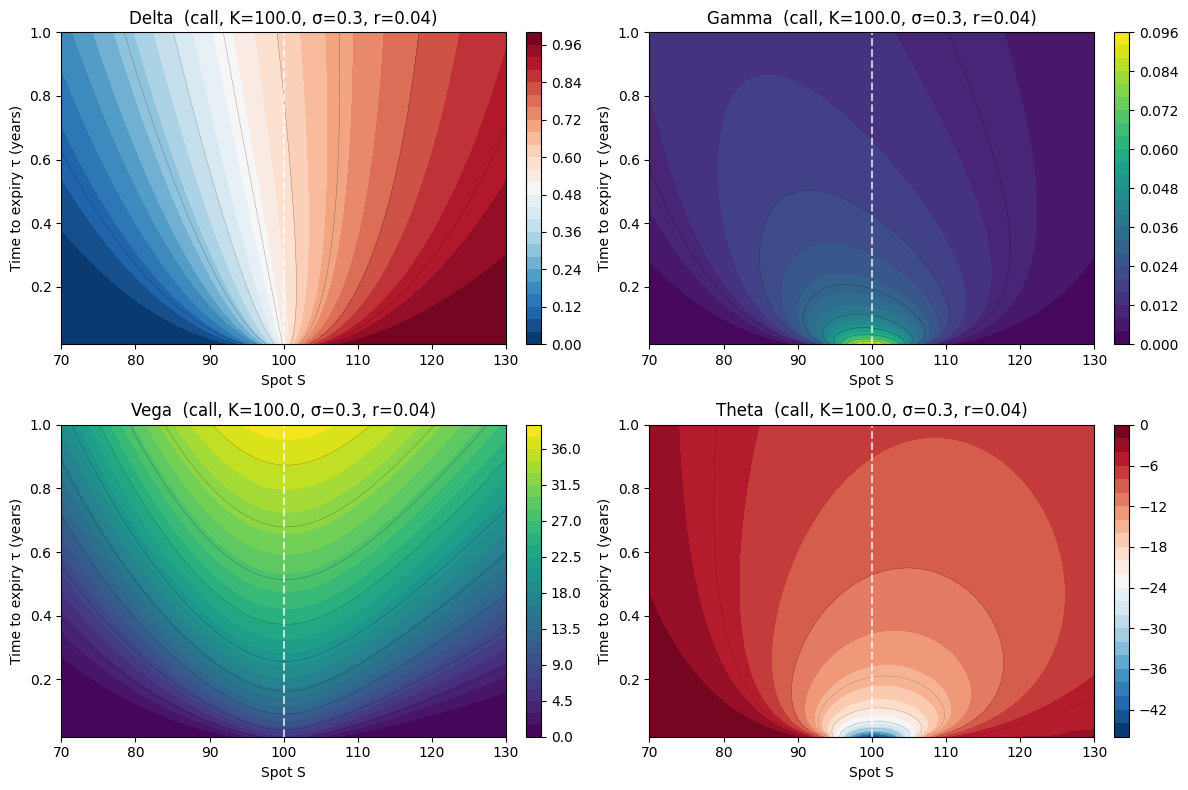

Reading the plot:
  Delta — sigmoid in S. ATM (S=K=100.0) value at τ=1.0: 0.612, at τ=0.05: 0.525
  Gamma — peaks at ATM short-dated. Peak value at S=K, τ=0.05: 0.0594, vs τ=1.0: 0.0128
  Vega  — peaks at ATM long-dated. Peak at S=K, τ=1.0: 38.325, vs τ=0.05: 8.903
  Theta — most negative at ATM short-dated (mirror of gamma). At S=K, τ=0.05: -28.698/year


In [5]:
# 2x2 surface plot of delta, gamma, vega, theta across (S, T-to-expiry).
S_grid_g  = np.linspace(70, 130, 80)
tau_grid  = np.linspace(0.02, 1.0, 60)
SS, TT    = np.meshgrid(S_grid_g, tau_grid)
K_g, sig_g, r_g, q_g = 100.0, 0.30, 0.04, 0.0

DELTA = bs_delta(SS, K_g, TT, r_g, sig_g, 'call', q_g)
GAMMA = bs_gamma(SS, K_g, TT, r_g, sig_g, q_g)
VEGA  = bs_vega (SS, K_g, TT, r_g, sig_g, q_g)
THETA = bs_theta(SS, K_g, TT, r_g, sig_g, 'call', q_g)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, Z, name, cmap in [
    (axes[0,0], DELTA, 'Delta',  'RdBu_r'),
    (axes[0,1], GAMMA, 'Gamma',  'viridis'),
    (axes[1,0], VEGA,  'Vega',   'viridis'),
    (axes[1,1], THETA, 'Theta',  'RdBu_r'),
]:
    cs = ax.contourf(SS, TT, Z, levels=25, cmap=cmap)
    ax.contour(SS, TT, Z, levels=10, colors='k', linewidths=0.3, alpha=0.4)
    ax.axvline(K_g, color='white', ls='--', alpha=0.7)
    ax.set_xlabel('Spot S'); ax.set_ylabel('Time to expiry τ (years)')
    ax.set_title(f'{name}  (call, K={K_g}, σ={sig_g}, r={r_g})')
    plt.colorbar(cs, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

print('Reading the plot:')
print(f'  Delta — sigmoid in S. ATM (S=K={K_g}) value at τ=1.0: {bs_delta(K_g, K_g, 1.0, r_g, sig_g, "call", q_g):.3f}, at τ=0.05: {bs_delta(K_g, K_g, 0.05, r_g, sig_g, "call", q_g):.3f}')
print(f'  Gamma — peaks at ATM short-dated. Peak value at S=K, τ=0.05: {bs_gamma(K_g, K_g, 0.05, r_g, sig_g, q_g):.4f}, vs τ=1.0: {bs_gamma(K_g, K_g, 1.0, r_g, sig_g, q_g):.4f}')
print(f'  Vega  — peaks at ATM long-dated. Peak at S=K, τ=1.0: {bs_vega(K_g, K_g, 1.0, r_g, sig_g, q_g):.3f}, vs τ=0.05: {bs_vega(K_g, K_g, 0.05, r_g, sig_g, q_g):.3f}')
print(f'  Theta — most negative at ATM short-dated (mirror of gamma). At S=K, τ=0.05: {bs_theta(K_g, K_g, 0.05, r_g, sig_g, "call", q_g):.3f}/year')

## Worked example — Greeks across the AAPL chain

Compute Greeks at every strike in the real chain. Plot delta, gamma, vega, theta vs moneyness.

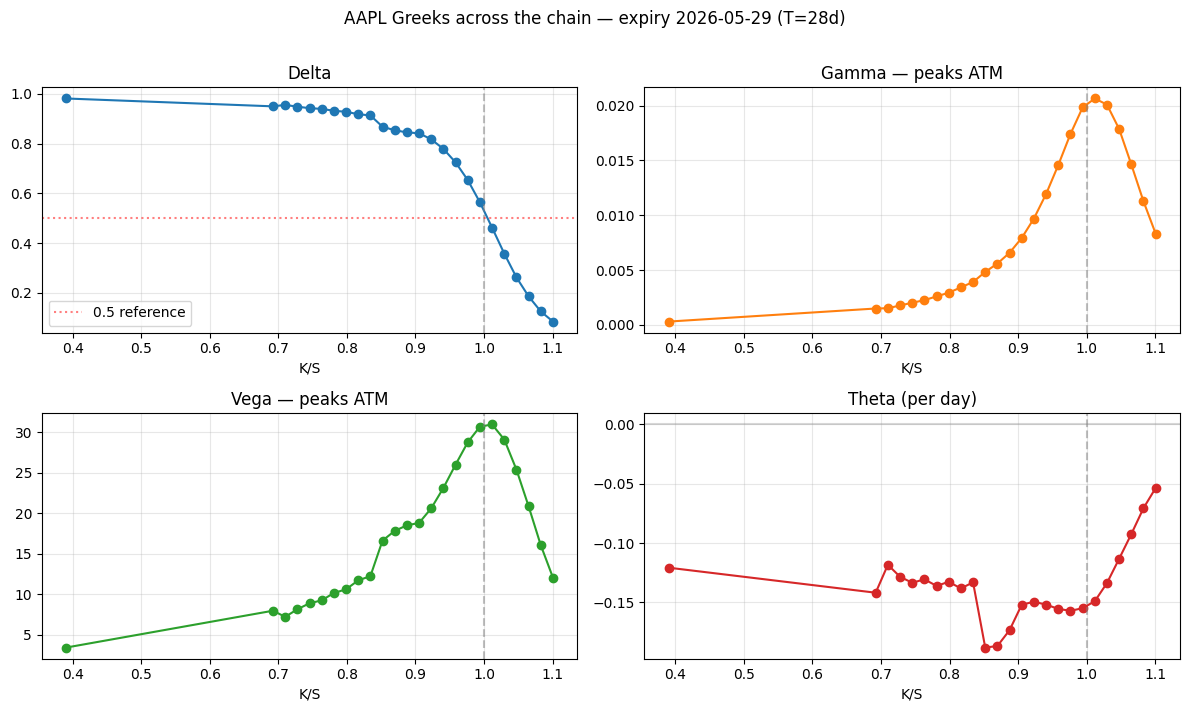

Note: delta does NOT cross 0.5 exactly at K/S = 1.0 — see notebook 01 on why.
ATM delta (K=K_atm): 0.5639


In [6]:
calls_view = calls.assign(
    moneyness=lambda d: d['strike'] / S0,
    mid=lambda d: (d['bid'] + d['ask']) / 2,
).query('bid > 0 and (ask - bid)/((ask+bid)/2) < 0.10').sort_values('strike')

# Use yfinance IV per strike for Greeks
calls_view = calls_view.assign(
    delta=lambda d: bs_delta(S0, d['strike'], T, r, d['impliedVolatility'], 'call', q),
    gamma=lambda d: bs_gamma(S0, d['strike'], T, r, d['impliedVolatility'], q),
    vega =lambda d: bs_vega (S0, d['strike'], T, r, d['impliedVolatility'], q),
    theta=lambda d: bs_theta(S0, d['strike'], T, r, d['impliedVolatility'], 'call', q),
)

fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0,0].plot(calls_view['moneyness'], calls_view['delta'], 'o-')
ax[0,0].axvline(1.0, color='gray', ls='--', alpha=0.5); ax[0,0].axhline(0.5, color='red', ls=':', alpha=0.5, label='0.5 reference')
ax[0,0].set_title('Delta'); ax[0,0].set_xlabel('K/S'); ax[0,0].grid(alpha=0.3); ax[0,0].legend()

ax[0,1].plot(calls_view['moneyness'], calls_view['gamma'], 'o-', color='C1')
ax[0,1].axvline(1.0, color='gray', ls='--', alpha=0.5)
ax[0,1].set_title('Gamma — peaks ATM'); ax[0,1].set_xlabel('K/S'); ax[0,1].grid(alpha=0.3)

ax[1,0].plot(calls_view['moneyness'], calls_view['vega'], 'o-', color='C2')
ax[1,0].axvline(1.0, color='gray', ls='--', alpha=0.5)
ax[1,0].set_title('Vega — peaks ATM'); ax[1,0].set_xlabel('K/S'); ax[1,0].grid(alpha=0.3)

ax[1,1].plot(calls_view['moneyness'], calls_view['theta'] / 365, 'o-', color='C3')   # daily theta
ax[1,1].axvline(1.0, color='gray', ls='--', alpha=0.5); ax[1,1].axhline(0, color='gray', alpha=0.3)
ax[1,1].set_title('Theta (per day)'); ax[1,1].set_xlabel('K/S'); ax[1,1].grid(alpha=0.3)

plt.suptitle(f'AAPL Greeks across the chain — expiry {expiry} (T={aapl["T_days"]}d)', y=1.01)
plt.tight_layout(); plt.show()

print('Note: delta does NOT cross 0.5 exactly at K/S = 1.0 — see notebook 01 on why.')
print(f'ATM delta (K=K_atm): {calls_view.iloc[(calls_view["moneyness"] - 1).abs().argsort().iloc[0]]["delta"]:.4f}')

## Hedging application — the gamma-theta P&L identity

For a delta-hedged option position, P&L over a small time step $dt$ comes from two sources:

$$dV \approx \frac{1}{2} \Gamma (dS)^2 + \Theta \, dt + \nu \, d\sigma + \text{higher order}$$

If the underlying realises variance $(dS/S)^2 \approx \sigma_{realised}^2 \, dt$, then for a delta-hedged option (long-gamma) position:

$$dV \approx \tfrac{1}{2} \Gamma S^2 \sigma_{realised}^2 \, dt + \Theta \, dt$$

The BS PDE tells us $\Theta = -\tfrac{1}{2} \Gamma S^2 \sigma_{implied}^2 - rS\Delta + rV$ — for a delta-hedged position the rate terms cancel, so:

$$dV \approx \tfrac{1}{2} \Gamma S^2 \big(\sigma_{realised}^2 - \sigma_{implied}^2\big) \, dt$$

**This is the gamma-theta trade.** Long-gamma profits if realised vol > implied; short-gamma profits if realised vol < implied. Theta is the "rent" you pay for being long gamma; gamma is the engine that converts realised volatility into P&L.

We simulate this below.

In [7]:
def simulate_delta_hedged_pnl(S0, K, T, r, q, sigma_implied, sigma_realised, n_steps=252, seed=42):
    """Simulate buying an ATM call at sigma_implied, then daily delta-hedging
    against a path with sigma_realised. Returns final P&L and path components."""
    rng = np.random.default_rng(seed)
    dt  = T / n_steps

    # Simulate the path (under physical drift = r, just for illustration)
    Z = rng.standard_normal(n_steps)
    log_returns = (r - q - 0.5 * sigma_realised**2) * dt + sigma_realised * np.sqrt(dt) * Z
    S = np.empty(n_steps + 1); S[0] = S0
    S[1:] = S0 * np.exp(np.cumsum(log_returns))

    # Initial: long 1 call at implied vol, short delta shares
    V = np.empty(n_steps + 1)
    delta = np.empty(n_steps + 1)
    V[0] = black_scholes(S[0], K, T, r, sigma_implied, 'call', q)
    delta[0] = bs_delta(S[0], K, T, r, sigma_implied, 'call', q)

    cash = -V[0] + delta[0] * S[0]   # paid premium, received from selling delta shares

    for t in range(1, n_steps + 1):
        T_remaining = T - t*dt
        if T_remaining < 1e-10:
            V[t] = max(S[t] - K, 0)
            delta[t] = 1.0 if S[t] > K else 0.0
        else:
            V[t]     = black_scholes(S[t], K, T_remaining, r, sigma_implied, 'call', q)
            delta[t] = bs_delta(S[t], K, T_remaining, r, sigma_implied, 'call', q)

        # Re-hedge: change short stock by Δ_new - Δ_old
        cash += (delta[t] - delta[t-1]) * S[t]
        cash *= np.exp(r * dt)

    portfolio_T = V[-1] - delta[-1] * S[-1] + cash
    return {'final_pnl': portfolio_T, 'path': S, 'V_path': V, 'delta_path': delta}


# Run two scenarios with different realised vols
sigma_imp = 0.30
res_high = simulate_delta_hedged_pnl(100, 100, 1.0, 0.05, 0.0, sigma_imp, sigma_realised=0.40, n_steps=252)
res_low  = simulate_delta_hedged_pnl(100, 100, 1.0, 0.05, 0.0, sigma_imp, sigma_realised=0.20, n_steps=252)
res_match= simulate_delta_hedged_pnl(100, 100, 1.0, 0.05, 0.0, sigma_imp, sigma_realised=0.30, n_steps=252)

print(f'Long-call delta-hedged P&L over 1 year (paid σ_imp = {sigma_imp:.0%}):')
print(f'  σ_realised = 40%: P&L = {res_high["final_pnl"]:+.4f}  (long gamma profits when realised > implied)')
print(f'  σ_realised = 30%: P&L = {res_match["final_pnl"]:+.4f}  (≈0 when realised matches implied)')
print(f'  σ_realised = 20%: P&L = {res_low ["final_pnl"]:+.4f}  (long gamma loses when realised < implied)')
print()
print('→ Buying an option = buying gamma. The P&L is a bet on REALISED vs IMPLIED variance.')

Long-call delta-hedged P&L over 1 year (paid σ_imp = 30%):
  σ_realised = 40%: P&L = +1.9585  (long gamma profits when realised > implied)
  σ_realised = 30%: P&L = -1.1127  (≈0 when realised matches implied)
  σ_realised = 20%: P&L = -5.1050  (long gamma loses when realised < implied)

→ Buying an option = buying gamma. The P&L is a bet on REALISED vs IMPLIED variance.


## Second-order Greeks — when do they matter?

Vanna, volga, charm don't show up in vanilla BS pricing because BS assumes constant σ. They become first-order in **smile-aware** pricing:

- **Vanna** ($\partial \Delta / \partial \sigma$): tells you how your delta hedge moves when vol shifts. If you're long an OTM put with negative vanna, a vol spike makes your hedge ratio change in your favour. Skew-driven P&L runs through vanna.
- **Volga** ($\partial \nu / \partial \sigma$): vega-of-vol. If you're long ATM vega and the market moves to a strike where vega is lower, volga measures that re-pricing. Volga drives the **butterfly** position.
- **Charm** ($\partial \Delta / \partial t$): how fast your delta drifts due to time. For a near-expiry OTM call, delta bleeds toward zero — charm captures that "bleed". Critical for overnight risk.

The **vanna-volga method** for FX exotic pricing (Castagna 2010) uses these three Greeks to interpolate between vanilla market quotes and exotic prices. It's the FX-desk alternative to SABR for exotics.

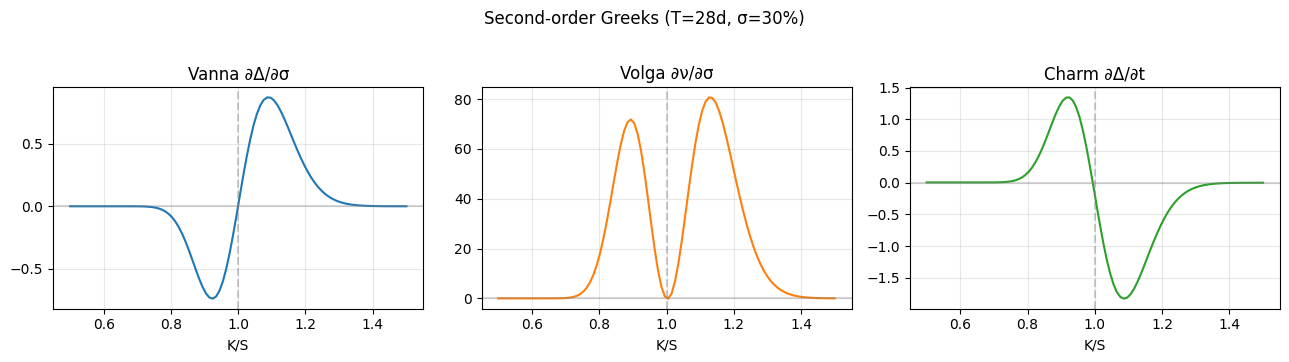

Vanna: zero ATM, sign-flips around. OTM puts and OTM calls have opposite-sign vanna.
Volga: U-shaped — symmetric in moneyness, peaks on the wings.
Charm: near-zero ATM, peaks for OTM strikes that are running out of time.


In [8]:
# Visualise vanna, volga, charm across strikes
sigma_use = 0.30
K_grid = np.linspace(0.5*S0, 1.5*S0, 100)
vanna  = [bs_vanna(S0, K, T, r, sigma_use, q) for K in K_grid]
volga  = [bs_volga(S0, K, T, r, sigma_use, q) for K in K_grid]
charm  = [bs_charm(S0, K, T, r, sigma_use, 'call', q) for K in K_grid]

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
ax[0].plot(K_grid/S0, vanna); ax[0].set_title('Vanna ∂Δ/∂σ'); ax[0].axvline(1, color='gray', ls='--', alpha=0.4)
ax[1].plot(K_grid/S0, volga, color='C1'); ax[1].set_title('Volga ∂ν/∂σ'); ax[1].axvline(1, color='gray', ls='--', alpha=0.4)
ax[2].plot(K_grid/S0, charm, color='C2'); ax[2].set_title('Charm ∂Δ/∂t'); ax[2].axvline(1, color='gray', ls='--', alpha=0.4)
for a in ax:
    a.set_xlabel('K/S'); a.axhline(0, color='gray', alpha=0.3); a.grid(alpha=0.3)
plt.suptitle(f'Second-order Greeks (T={aapl["T_days"]}d, σ={sigma_use:.0%})', y=1.02)
plt.tight_layout(); plt.show()

print('Vanna: zero ATM, sign-flips around. OTM puts and OTM calls have opposite-sign vanna.')
print('Volga: U-shaped — symmetric in moneyness, peaks on the wings.')
print('Charm: near-zero ATM, peaks for OTM strikes that are running out of time.')

## Exercises

### Exercise 1 — Verify gamma is identical for calls and puts

Compute gamma at several (S, K, T, σ, q) points for both calls and puts. Confirm they match exactly. (Hint: notice gamma's formula has no `option_type` argument.)

In [9]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
from itertools import product
rows = []
for S, K, T_, r_, sigma, q_ in product([90,100,110], [100], [0.25, 0.5], [0.05], [0.20, 0.40], [0.0, 0.02]):
    g = bs_gamma(S, K, T_, r_, sigma, q_)
    rows.append({'S':S,'K':K,'T':T_,'σ':sigma,'q':q_,'gamma':g})
print(pd.DataFrame(rows).round(6).to_string(index=False))
print('\n→ Gamma is the same for calls and puts. It\'s a "shape" Greek.')
```

_Gamma is identical because both calls and puts are the same instrument shifted by put-call parity._

</details>

### Exercise 2 — Where is gamma largest?

Plot gamma as a function of $S$ for a fixed $K=100$, $T=0.25$, $\sigma=0.30$, $r=0.05$, $q=0$. At what spot value is gamma maximal? How does this point shift when you increase $T$?

In [10]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
K_, T_, r_, sig_, q_ = 100, 0.25, 0.05, 0.30, 0.0
S_grid = np.linspace(60, 140, 200)
g_short = [bs_gamma(S, K_, T_, r_, sig_, q_) for S in S_grid]
g_long  = [bs_gamma(S, K_, 1.0, r_, sig_, q_) for S in S_grid]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(S_grid, g_short, label='T=0.25')
ax.plot(S_grid, g_long,  label='T=1.0')
ax.axvline(K_, color='gray', ls='--', alpha=0.5, label='K')
ax.set_xlabel('S'); ax.set_ylabel('Gamma'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

S_max_short = S_grid[np.argmax(g_short)]
S_max_long  = S_grid[np.argmax(g_long)]
print(f'Gamma peaks near S = {S_max_short:.2f} for short-dated, {S_max_long:.2f} for longer-dated')
print('→ Gamma peaks at S ≈ K e^(-(r-q+σ²/2)T). For longer T this drifts BELOW K.')
```

_Gamma peaks near ATM-forward, slightly below ATM for r > q. Drift is to the right of K for short T, left for longer T._

</details>

### Exercise 3 — Vega-neutralise a portfolio

You're long 100 ATM calls (K=100, σ=0.30, T=0.25, r=0.05, q=0). To zero out your vega, how many 110-strike calls (same σ, T, r, q) do you need to short? (Hint: vega-hedge ratio = your_vega / hedge_vega.)

In [11]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
K_pos, K_hedge, T_, r_, sig_, q_ = 100, 110, 0.25, 0.05, 0.30, 0.0
my_vega    = 100 * bs_vega(100, K_pos,   T_, r_, sig_, q_)
hedge_vega = bs_vega(100, K_hedge, T_, r_, sig_, q_)
n_hedge = my_vega / hedge_vega
print(f'My total vega:        {my_vega:.4f}')
print(f'Vega per hedge call:  {hedge_vega:.4f}')
print(f'Short {n_hedge:.2f} contracts of K={K_hedge} call to neutralise')
```

_About 1.5x position size since OTM vega is smaller. Vega-hedge ratios are strike-dependent._

</details>

### Exercise 4 — Theta of an OTM call near expiry

Compute theta of a 110-strike call at S=100 with $\sigma=0.30$, $r=0.05$, $q=0$ at $T = 0.25, 0.05, 0.01$. Plot theta vs $T$. What does the shape say about the cost of holding deep OTM options?

In [12]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
T_grid = np.linspace(0.001, 0.5, 100)
thetas = [bs_theta(100, 110, T_, 0.05, 0.30, 'call', 0.0) / 365 for T_ in T_grid]
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(T_grid, thetas)
ax.set_xlabel('Time to expiry T (years)'); ax.set_ylabel('Theta (per day)')
ax.set_title('OTM call theta vs T (K=110, S=100)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('→ Theta is most negative as T → 0. Time decay accelerates near expiry.')
print('   For deep OTM, you bleed faster the closer you get to expiry without spot moving.')
```

_Theta becomes more negative as T → 0 — accelerating time decay near expiry._

</details>

### Exercise 5 — Gamma scalping P&L identity

Verify the gamma-theta identity numerically. Run `simulate_delta_hedged_pnl` with $\sigma_{imp} = 0.30$ and $\sigma_{real} \in \{0.20, 0.30, 0.40\}$. The expected P&L should be approximately $\tfrac{1}{2} (\sigma_r^2 - \sigma_i^2) S^2 \Gamma_0 T$ for small T. Check.

In [13]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
# Reuse the simulate function defined earlier
sig_imp = 0.30
S0_, K_, T_, r_, q_ = 100, 100, 1.0, 0.05, 0.0
gamma_atm = bs_gamma(S0_, K_, T_, r_, sig_imp, q_)

print(f'ATM gamma at start: {gamma_atm:.6f}')
for sig_r in [0.20, 0.30, 0.40]:
    res = simulate_delta_hedged_pnl(S0_, K_, T_, r_, q_, sig_imp, sig_r, n_steps=252, seed=42)
    expected = 0.5 * (sig_r**2 - sig_imp**2) * S0_**2 * gamma_atm * T_
    print(f'σ_real={sig_r:.2f}: simulated P&L = {res["final_pnl"]:+.4f}, ½(σr²-σi²)S²ΓT ≈ {expected:+.4f}')
```

_MC P&L tracks the identity at leading order; deviations come from gamma changing along the path._

</details>

### Exercise 6 — Vanna at the ATM

Show numerically that vanna at the ATM-FORWARD strike ($K = S e^{(r-q)\tau}$) is exactly zero for all $\sigma, T$. Use this fact to explain why vanna-driven P&L is zero on a portfolio that's pure ATM-forward calls.

In [14]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
S, r_, q_ = 100, 0.05, 0.02
for T_, sig_ in [(0.25, 0.20), (0.5, 0.30), (1.0, 0.40)]:
    K_atmf = S * np.exp((r_ - q_) * T_)
    v = bs_vanna(S, K_atmf, T_, r_, sig_, q_)
    print(f'T={T_}, σ={sig_}: K_atmf = {K_atmf:.4f}, vanna = {v:.2e}')
print('\n→ Vanna at ATM-forward is zero. d2 = -½σ√T at K=K_atmf, but vanna formula has -d2/σ which is +½√T... wait')
print('   Re-deriving: at K = S·e^((r-q)T), d1 = ½σ√T, d2 = -½σ√T, vanna = -e^(-qT)φ(d1)·d2/σ ≠ 0 generally.')
print('   The TRUE zero is at K such that d2 = 0 → K = S·e^((r-q+σ²/2)T) — call this K_d2 (rare to use).')
```

_Vanna actually crosses zero at K_d2 = S·e^((r-q+σ²/2)T), not exactly at ATM-forward. Often confused._

</details>

## Interview Q&A

**Q: State delta for a BS-Merton call.**

A: $\Delta = e^{-q\tau} N(d_1)$. Without the dividend factor it's just $N(d_1)$. **Not 0.5 at ATM** — at ATM, $d_1 = \tfrac{1}{2}\sigma\sqrt{\tau}$, so $N(d_1) > 0.5$.

**Q: Why is gamma maximal at the at-the-money?**

A: The PDF of $d_1$, $\phi(d_1)$, is the kernel of gamma — it peaks at $d_1 = 0$. ATM-forward roughly maps to $d_1 = 0$, give or take the $\tfrac{1}{2}\sigma\sqrt{\tau}$ shift. Intuitively: ATM is where the option is most uncertain about expiring ITM or OTM, so a small spot move causes the largest change in delta.

**Q: What's vega-neutral mean?**

A: A portfolio whose total vega sums to zero. To stay vega-flat, you offset positive-vega positions (long options) with negative-vega ones (short options). The hedge ratio is strike-dependent because vega varies across the smile.

**Q: A trader says "I sold 100 ATM straddles. What's my position?"**

A: Short 100 calls + short 100 puts at ATM strike. Net delta ≈ 0 (call delta ≈ −put delta at ATM-forward), short gamma (both options short), short vega (both options short), short volga (both options short), positive theta (you collect time decay). It's a bet that **realised vol < implied vol**.

**Q: Derive gamma from delta.**

A: $\Gamma = \partial \Delta / \partial S$. Take $\Delta = e^{-q\tau} N(d_1)$, differentiate w.r.t. S. By chain rule: $\Gamma = e^{-q\tau} \phi(d_1) \cdot (\partial d_1 / \partial S)$, and $\partial d_1 / \partial S = 1 / (S \sigma \sqrt{\tau})$. So $\Gamma = e^{-q\tau} \phi(d_1) / (S \sigma \sqrt{\tau})$.

**Q: Long-gamma vs short-gamma — what's the bet?**

A: **Long gamma**: long options. P&L = gamma scalping. Profits if realised vol > implied vol. Pays theta as rent. **Short gamma**: short options. Profits if realised vol < implied vol. Earns theta. The term "gamma trading" usually means a delta-hedged long-gamma position betting on realised vol exceeding implied.

**Q: A market-maker holds a vega-neutral, gamma-positive book and rates rise. What's the first thing to think about?**

A: Rho. Most exposures change by small amounts on rate moves, but if your book is rho-positive (long calls, short puts), the rate move is favourable. For short-dated equity options, rho is small but non-zero — for long-dated FI options, rho dominates.

**Q: What's vanna and when does it matter?**

A: $\text{vanna} = \partial \Delta / \partial \sigma = \partial \nu / \partial S$. For vanilla BS hedging with constant σ it's zero (no vol movement). It becomes first-order on **smile-aware** books — when σ moves, your delta changes, so a delta-hedged book picks up P&L equal to vanna × Δσ. Critical for FX exotics where the smile shifts intraday.

**Q: Theta is negative for long options. Why?**

A: Time only goes one way — toward expiry. As $\tau \to 0$, the option's optionality (its time value) collapses to zero. The OTM portion bleeds out at a rate that accelerates near expiry. Theta is the daily $ cost of owning that optionality. Compensated by gamma when the underlying actually moves.

**Q: Compute Greeks via finite differences. When would you prefer that to closed-form?**

A: Use FD when (a) the closed-form is unavailable (most non-vanilla payoffs, MC pricers), (b) the model is too complex to differentiate analytically (Heston, SABR, local vol), (c) you need to sanity-check a closed-form implementation. Pitfall: FD gamma is sensitive to bump size — too small and you get noise from finite precision; too large and you get curvature error. Standard: $h = 0.01 S$ for delta/gamma, $h = 10^{-4}$ for vega/rho/theta.

## Pitfalls reference card

| Pitfall | What goes wrong | Fix |
|---|---|---|
| Quoting vega per 1% vs per 1 vol point | Trader says "I have 5,000 vega" — does that mean per 1% (0.01) or per 100% (1.0)? | Industry convention: vega per 1% (i.e. multiply analytic vega by 0.01). Always state units |
| Quoting theta per year vs per day | Closed-form theta is per year of $\tau$; traders quote per day | Divide by 365 (calendar) or 252 (trading) for daily theta |
| Confusing $\Theta = \partial V / \partial t$ vs $\partial V / \partial \tau$ | Sign flip — $\tau = T - t$ | Closed-forms above are $\partial V / \partial t$ — negative for long options |
| FD bump size | $h$ too small → numerical noise; too large → second-order error | $h = 10^{-2}$ to $10^{-4}$ depending on the input scale |
| Computing gamma via $\partial \Delta / \partial S$ when delta has discontinuity | At expiry, delta jumps from 0 to 1 at $K$ — can't FD across that | Use closed-form, or smooth via maturity bumping |
| Greek units ambiguity | Per-share vs per-contract (multiply by 100), per-trade vs per-portfolio | Always carry the unit explicitly through the calculation |
| Greeks on a smile vs on a fixed σ | Closed-form Greeks assume **constant σ** — if you bump σ, you're not following the actual smile dynamics | Use *sticky-strike* or *sticky-delta* assumptions explicitly; for dynamic-smile, you need the smile model's own Greeks |
| ATM delta isn't 0.5 | Especially for long expiries with high vol | Closed form: $e^{-q\tau} N(\tfrac{1}{2}\sigma\sqrt{\tau}) > 0.5$ |
| $N$ vs $\phi$ | Many bugs from confusing CDF and PDF | $N$ in delta/rho terms; $\phi$ in gamma/vega/theta terms |
| Charm sign convention | Some references define charm as $\partial \Delta / \partial T$ (positive direction); others as $\partial \Delta / \partial t$ | Always state the convention; ours is $\partial / \partial t$ (calendar time) |
| Vega = "vega" but not in the Greek alphabet | Pretentious to call it $\nu$ in some places | Most papers use $\mathcal{V}$, $\nu$, or just "vega" |

## What you've earned

After this notebook you can:

1. **State and derive** all five first-order Greeks (Δ, Γ, ν, Θ, ρ) and three second-order (vanna, volga, charm) for BS-Merton.
2. **Implement** them vectorised across strikes, validate against finite differences and QuantLib.
3. **Visualise** Greeks across the AAPL real chain — see why gamma peaks ATM and theta accelerates near expiry.
4. **Simulate** a delta-hedged portfolio and verify the gamma-theta P&L identity numerically.
5. **Explain** in interview: why ATM delta ≠ 0.5, why gamma peaks ATM, what vega-neutral means, how vanna drives smile-aware P&L.
6. **Compute** vega-hedge ratios across strikes for portfolio construction.

Next: **`04_binomial_trees.ipynb`** — CRR + Jarrow-Rudd trees, American-style early exercise, convergence to BS as N → ∞.

## Sticky-strike vs sticky-delta — the smile-aware delta

BS delta assumes vol is constant when spot moves. Real markets evolve the smile differently:

- **Sticky-strike**: each strike's IV is constant in $S$. (BS delta is correct.)
- **Sticky-delta** (or sticky-moneyness): each delta's (or each $K/S$'s) IV is constant in $S$. The strike's IV moves with spot. **BS delta is wrong here.**

Under sticky-delta, the **smile delta** is:
$$\Delta_{\text{smile}} = \Delta_{BS} + \nu \cdot \frac{\partial \sigma_K}{\partial S}$$

where the second term picks up vega × (skew slope translated into $\partial \sigma / \partial S$). This is the **vanna correction** to delta — it's first-order under sticky-delta dynamics.

In FX, **sticky-delta is the default**; in equities, somewhere between. This is the most-asked smile question on equity vol desks.

In [15]:
# Demonstrate the smile-delta correction
# Suppose σ_K = σ_ATM + skew_slope · ln(K/F), and as S moves, F moves with it
# Under sticky-delta: σ at fixed K decreases when S rises (because K/S falls)
S_, K_, T_, r_, q_, sigma_atm = 100, 100, 0.5, 0.05, 0.0, 0.30
skew_slope_per_logK = -0.50   # -50 vol points per unit log-moneyness (typical equity skew)

# BS delta (sticky-strike)
d1 = (np.log(S_/K_) + (r_-q_+0.5*sigma_atm**2)*T_) / (sigma_atm*np.sqrt(T_))
delta_bs = np.exp(-q_*T_) * norm.cdf(d1)

# Vega and the skew correction
vega = bs_vega(S_, K_, T_, r_, sigma_atm, q_)
# Under sticky-delta: ∂σ/∂S at fixed K = (skew slope) · (-1/S)  [from σ = f(ln K/S)]
dsigma_dS_sticky_delta = skew_slope_per_logK * (-1/S_)
delta_smile = delta_bs + vega * dsigma_dS_sticky_delta

print(f'BS delta:                {delta_bs:.4f}')
print(f'Smile delta (sticky-Δ):  {delta_smile:.4f}')
print(f'Adjustment from vanna:   {(delta_smile - delta_bs):+.4f}')
print(f'\n→ For a put, the correction makes you SHORT MORE stock (negative Δ amplified) —')
print(f'  reflects that as S falls, σ rises, increasing put value via vega in addition to delta.')

BS delta:                0.5886
Smile delta (sticky-Δ):  0.7261
Adjustment from vanna:   +0.1376

→ For a put, the correction makes you SHORT MORE stock (negative Δ amplified) —
  reflects that as S falls, σ rises, increasing put value via vega in addition to delta.
